# Phase 9 - Evaluation with RAGAS

**Goal**: Build a comprehensive evaluation pipeline using RAGAS metrics to compare three RAG pipeline configurations end-to-end.

## What this notebook does

1. **Ground truth** - Load manually written reference answers for the 25 benchmark questions
2. **Pipeline evaluation** - Run three pipeline configs through RAGAS:
   - `naive`: dense similarity only (baseline)
   - `hybrid_reranked`: BM25 + dense + cross-encoder reranking
   - `hyde`: HyDE query expansion + dense similarity
3. **RAGAS metrics**: Faithfulness, Answer Relevancy, Context Precision, Context Recall
4. **Visualization**: Radar chart and bar chart per metric

## RAGAS metrics overview

| Metric | Measures | Requires |
|--------|----------|----------|
| **Faithfulness** | Is the answer supported by the context? (no hallucinations) | LLM |
| **Answer Relevancy** | Does the answer address the question? | LLM + Embeddings |
| **Context Precision** | Are retrieved docs relevant to the question? | LLM |
| **Context Recall** | Does context cover all info needed to answer? | LLM + ground_truth |

> **Note on ground truths**: Reference answers were written manually - not generated by Mistral - to avoid circular evaluation bias. All RAGAS scoring calls use local Mistral 7B via Ollama.

## 0. Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress RAGAS deprecation warnings (LangchainLLMWrapper is deprecated but still works)
warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# LangChain imports
from langchain_ollama import ChatOllama
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# RAGAS
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Paths
EVAL_DIR     = PROJECT_ROOT / "data" / "evaluation"
RESULTS_DIR  = PROJECT_ROOT / "results"
PERSIST_DIR  = PROJECT_ROOT / "vectorstore" / "chroma_db"
MODELS_YAML  = PROJECT_ROOT / "configs" / "models.yaml"
GT_PATH      = EVAL_DIR / "ground_truth.json"
RESULTS_PATH = RESULTS_DIR / "ragas_evaluation.json"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Models
LLM_MODEL = "mistral:7b"

# Evaluation subset - RAGAS is slow (many LLM calls per question)
# We evaluate on N_EVAL questions per category to keep runtime manageable
N_EVAL = 3   # 3 questions per category -> 12 total (4 categories)

print("Setup complete.")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Chroma DB    : {PERSIST_DIR}")
print(f"  Eval subset  : {N_EVAL} questions/category")

d:\Astyan\rag-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.
  Project root : D:\Astyan\rag-exploration
  Chroma DB    : D:\Astyan\rag-exploration\vectorstore\chroma_db
  Eval subset  : 3 questions/category


In [2]:
from src.embeddings.models import create_from_registry

# Initialize models - same pattern as notebooks 04-08
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
llm = ChatOllama(model=LLM_MODEL, temperature=0.0)

EMBED_MODEL = emb_info.name

# RAGAS wrappers for local models
ragas_llm = LangchainLLMWrapper(llm)
ragas_emb = LangchainEmbeddingsWrapper(embeddings)

# Warmup
_ = llm.invoke("Hi")
print(f"LLM ready : {LLM_MODEL}")
print(f"Embeddings: {EMBED_MODEL}")

LLM ready : mistral:7b
Embeddings: mxbai_large


## 1. Ground Truth

RAGAS `context_recall` requires a reference answer (`ground_truth`) to measure whether the retrieved context contains all the information needed to answer.

The ground truths in `data/evaluation/ground_truth.json` were **written manually** based on LangChain documentation knowledge. This is critical: using the same model (Mistral 7B) to both generate answers and evaluate them creates circular scoring bias.

Each ground truth is a 3-5 sentence factual summary covering the key points a correct answer must include.

In [3]:
# Load manually written ground truths
with open(GT_PATH, "r", encoding="utf-8") as f:
    ground_truths = json.load(f)

print(f"Loaded {len(ground_truths)} ground truths from {GT_PATH.name}")
print(f"\nSample:")
sample = ground_truths[0]
print(f"  Q: {sample['question']}")
print(f"  A: {sample['ground_truth'][:200]}...")

Loaded 25 ground truths from ground_truth.json

Sample:
  Q: What is RAG and how does it work?
  A: RAG (Retrieval-Augmented Generation) is a technique that grounds LLM responses in external knowledge. It works in two stages: first, a retriever fetches relevant documents from a knowledge base (e.g. ...


In [4]:
# Select N_EVAL questions per category for evaluation
from collections import defaultdict

by_category = defaultdict(list)
for item in ground_truths:
    by_category[item["category"]].append(item)

eval_questions = []
for cat, items in by_category.items():
    subset = items[:N_EVAL]
    eval_questions.extend(subset)
    print(f"  {cat}: {len(subset)} questions")

print(f"\nTotal evaluation questions: {len(eval_questions)}")

  conceptual: 3 questions
  technical: 3 questions
  how_to: 3 questions
  error_related: 3 questions

Total evaluation questions: 12


## 2. Vector Store Setup

Load the raw core docs, chunk them, and build a dedicated ChromaDB collection for this evaluation. The collection is reused on subsequent runs if it already exists.

In [5]:
from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus

# Same loading pipeline as all previous phases (04-08)
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Core docs: {len(core_docs)} (from {len(docs)} raw, {len(cleaned_docs)} cleaned)")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Core docs: 130 (from 1463 raw, 1445 cleaned)


In [6]:
from src.ingestion.chunkers import chunk_recursive

# Chunk the core docs - same function and parameters as notebooks 04-08
chunking_result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = chunking_result.chunks
print(f"Chunks: {len(chunks)}")

# Build or reuse ChromaDB collection
COLLECTION_NAME = "ragas_eval_mxbai"

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(PERSIST_DIR),
)

existing = vectorstore.get()
if len(existing["ids"]) == 0:
    print(f"Building collection '{COLLECTION_NAME}' ({len(chunks)} chunks)...")
    import time
    t0 = time.perf_counter()
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=str(PERSIST_DIR),
    )
    print(f"Indexed in {time.perf_counter()-t0:.1f}s")
else:
    print(f"Reusing existing collection '{COLLECTION_NAME}' ({len(existing['ids'])} docs)")

Chunks: 2217
Reusing existing collection 'ragas_eval_mxbai' (7012 docs)


In [7]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(chunks, k=5)
print(f"BM25 retriever built ({len(chunks)} docs)")

BM25 retriever built (2217 docs)


## 3. Pipeline Definitions

Three configurations to evaluate:

| Config | Retrieval | Reranking | Query Transform |
|--------|-----------|-----------|----------------|
| `naive` | Dense similarity (top-5) | No | None |
| `hybrid_reranked` | BM25 + Dense, top-20 candidates | Cross-encoder | None |
| `hyde` | HyDE expansion + dense similarity | No | HyDE |

Each config uses the same generation chain: a simple RAG prompt with Mistral 7B.

In [8]:
# Shared RAG generation prompt
RAG_PROMPT = ChatPromptTemplate.from_messages([
    (
        "human",
        """Answer the following question using ONLY the provided context.
If the context does not contain enough information, say so.
Be concise and accurate.

Context:
{context}

Question: {question}

Answer:""",
    ),
])

def make_rag_chain(retriever):
    """Build a simple RAG chain: retrieve -> format -> generate."""
    from langchain_core.runnables import RunnablePassthrough, RunnableLambda

    def format_docs(docs):
        return "\n\n".join(
            f"[{i+1}] {d.page_content[:800]}" for i, d in enumerate(docs)
        )

    chain = (
        {
            "context": retriever | RunnableLambda(format_docs),
            "question": RunnablePassthrough(),
        }
        | RAG_PROMPT
        | llm
        | StrOutputParser()
    )
    return chain

print("RAG prompt defined.")

RAG prompt defined.


In [9]:
# Config 1: Naive - dense similarity top-5
naive_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
naive_chain = make_rag_chain(naive_retriever)
print("Config 'naive' ready.")

Config 'naive' ready.


In [10]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document as LCDocument
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from sentence_transformers import CrossEncoder

# Config 2: Hybrid (BM25 + Dense) + Cross-encoder reranking

class HybridRerankedRetriever(BaseRetriever):
    """BM25 + dense ensemble retriever with cross-encoder reranking."""

    base_retriever: object
    model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    top_k: int = 5
    _cross_encoder: object = None

    class Config:
        arbitrary_types_allowed = True

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> list[LCDocument]:
        if self._cross_encoder is None:
            object.__setattr__(self, "_cross_encoder", CrossEncoder(self.model_name))
        candidates = self.base_retriever.invoke(query)
        pairs = [(query, d.page_content) for d in candidates]
        scores = self._cross_encoder.predict(pairs).tolist()
        ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
        return [doc for doc, _ in ranked[:self.top_k]]

# Ensemble retriever: BM25 + Dense, 20 candidates each
dense_retriever_20 = vectorstore.as_retriever(search_kwargs={"k": 20})
bm25_retriever_20 = BM25Retriever.from_documents(chunks, k=20)

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever_20, dense_retriever_20],
    weights=[0.5, 0.5],
)

hybrid_reranked_retriever = HybridRerankedRetriever(
    base_retriever=ensemble_retriever,
    top_k=5,
)
hybrid_reranked_chain = make_rag_chain(hybrid_reranked_retriever)
print("Config 'hybrid_reranked' ready.")

Config 'hybrid_reranked' ready.


In [11]:
from langchain_core.runnables import RunnableLambda
from src.chains.query_translation import generate_hyde_doc

# Config 3: HyDE - generate hypothetical document, then retrieve

class HyDERetriever(BaseRetriever):
    """Retriever that first generates a hypothetical doc, then retrieves by it."""

    vectorstore: object
    llm: object
    k: int = 5

    class Config:
        arbitrary_types_allowed = True

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> list[LCDocument]:
        hyp_doc = generate_hyde_doc(self.llm, query)  # llm first, query second
        return self.vectorstore.similarity_search(hyp_doc, k=self.k)

hyde_retriever = HyDERetriever(vectorstore=vectorstore, llm=llm, k=5)
hyde_chain = make_rag_chain(hyde_retriever)
print("Config 'hyde' ready.")

Config 'hyde' ready.


## 4. Collect Samples for Each Configuration

Run retrieval + generation for all evaluation questions. This is the slow step.

Expected time per config: ~1-2 min for 12 questions (retrieval + Mistral generation).

In [12]:
import time
from src.evaluation.evaluator import EvalSample

def collect_samples_simple(chain, retriever, questions):
    """Run chain+retriever on each question, return EvalSample list."""
    samples = []
    for i, q in enumerate(questions):
        start = time.perf_counter()
        docs = retriever.invoke(q["question"])
        contexts = [d.page_content for d in docs]
        answer = chain.invoke(q["question"])
        if not isinstance(answer, str):
            answer = str(answer)
        latency_ms = (time.perf_counter() - start) * 1000
        samples.append(EvalSample(
            question=q["question"],
            answer=answer,
            contexts=contexts,
            ground_truth=q["ground_truth"],
            category=q["category"],
            question_id=q["id"],
            latency_ms=latency_ms,
        ))
        print(f"  [{i+1:02d}/{len(questions)}] {q['id']} ({latency_ms:.0f} ms)")
    return samples

configs = [
    ("naive",            naive_chain,            naive_retriever),
    ("hybrid_reranked",  hybrid_reranked_chain,  hybrid_reranked_retriever),
    ("hyde",             hyde_chain,             hyde_retriever),
]

all_samples: dict[str, list] = {}

for config_name, chain, retriever in configs:
    print(f"\n--- Collecting samples: {config_name} ---")
    t0 = time.perf_counter()
    samples = collect_samples_simple(chain, retriever, eval_questions)
    all_samples[config_name] = samples
    print(f"Done in {time.perf_counter()-t0:.1f}s")


--- Collecting samples: naive ---
  [01/12] c01 (3683 ms)
  [02/12] c02 (2171 ms)
  [03/12] c03 (2444 ms)
  [04/12] t01 (2461 ms)
  [05/12] t02 (1888 ms)
  [06/12] t03 (1050 ms)
  [07/12] h01 (1610 ms)
  [08/12] h02 (3741 ms)
  [09/12] h03 (10130 ms)
  [10/12] e01 (933 ms)
  [11/12] e02 (2427 ms)
  [12/12] e03 (3401 ms)
Done in 35.9s

--- Collecting samples: hybrid_reranked ---


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1537.56it/s, Materializing param=classifier.weight]                                    
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [01/12] c01 (4394 ms)
  [02/12] c02 (2716 ms)
  [03/12] c03 (3237 ms)
  [04/12] t01 (3269 ms)
  [05/12] t02 (5522 ms)
  [06/12] t03 (1864 ms)
  [07/12] h01 (7541 ms)
  [08/12] h02 (5079 ms)
  [09/12] h03 (5119 ms)
  [10/12] e01 (3483 ms)
  [11/12] e02 (3543 ms)
  [12/12] e03 (2803 ms)
Done in 48.6s

--- Collecting samples: hyde ---
  [01/12] c01 (7135 ms)
  [02/12] c02 (6903 ms)
  [03/12] c03 (4808 ms)
  [04/12] t01 (12004 ms)
  [05/12] t02 (11474 ms)
  [06/12] t03 (4549 ms)
  [07/12] h01 (15468 ms)
  [08/12] h02 (7784 ms)
  [09/12] h03 (7286 ms)
  [10/12] e01 (4872 ms)
  [11/12] e02 (6605 ms)
  [12/12] e03 (7563 ms)
Done in 96.5s


## 5. RAGAS Evaluation

Run the four RAGAS metrics on the collected samples for each configuration.

**Estimated time**: ~3-5 min per config (RAGAS makes multiple LLM calls per question).

> RAGAS internally calls the LLM to:
> - Decompose the answer into statements (faithfulness)
> - Generate questions from the answer (answer_relevancy)
> - Score each context chunk (context_precision, context_recall)

In [13]:
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas import evaluate
from datasets import Dataset

# Instantiate metric objects (RAGAS 0.4.x requires instances, not singletons)
faithfulness_metric    = Faithfulness(llm=ragas_llm)
answer_relevancy_metric = AnswerRelevancy(llm=ragas_llm, embeddings=ragas_emb)
context_precision_metric = ContextPrecision(llm=ragas_llm)
context_recall_metric   = ContextRecall(llm=ragas_llm)

METRICS = [
    faithfulness_metric,
    answer_relevancy_metric,
    context_precision_metric,
    context_recall_metric,
]
print(f"RAGAS metrics configured with local {LLM_MODEL} + {EMBED_MODEL}.")

RAGAS metrics configured with local mistral:7b + mxbai_large.


In [14]:
from ragas.run_config import RunConfig

eval_results: dict[str, dict] = {}

run_cfg = RunConfig(
    timeout=300,      # 5 min per LLM call (Mistral local is slow)
    max_retries=3,
    max_workers=1,    # sequential to avoid overwhelming Ollama
)

for config_name, samples in all_samples.items():
    print(f"\n--- RAGAS evaluation: {config_name} ({len(samples)} samples) ---")
    t0 = time.perf_counter()

    records = [
        {
            "question": s.question,
            "answer": s.answer,
            "contexts": s.contexts,
            "ground_truth": s.ground_truth,
        }
        for s in samples
    ]
    dataset = Dataset.from_list(records)

    result = evaluate(
        dataset=dataset,
        metrics=METRICS,
        run_config=run_cfg,
        raise_exceptions=False,
    )

    elapsed = time.perf_counter() - t0
    df = result.to_pandas()

    metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
    scores = {col: float(df[col].mean()) for col in metric_cols if col in df.columns}

    eval_results[config_name] = {
        "scores": scores,
        "df": df,
        "elapsed_s": elapsed,
        "samples": samples,
    }

    print(f"  elapsed: {elapsed:.1f}s")
    for k, v in scores.items():
        print(f"  {k}: {v:.4f}")


--- RAGAS evaluation: naive (12 samples) ---


Evaluating:  25%|██▌       | 12/48 [01:48<05:21,  8.93s/it]Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt statement_generator_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[12]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Evaluating:  62%|██████▎   | 30/48 [04:34<02:45,  9.17s/it]Exception raised in Job[30]: OutputParserException(Failed to parse StringIO from completion {"output": {"reason": "The output string complies with the given JSON Schema, using double quotes and properly escaped backslashes as required. The output provides an answer to the question 'How do I add stre

  elapsed: 470.0s
  faithfulness: 0.7467
  answer_relevancy: 0.6031
  context_precision: 0.9955
  context_recall: 0.7821

--- RAGAS evaluation: hybrid_reranked (12 samples) ---


Evaluating:  62%|██████▎   | 30/48 [05:11<03:11, 10.64s/it]Exception raised in Job[30]: OutputParserException(Failed to parse StringIO from completion {"output": {"reason": "The output string complies with the given JSON Schema, using double quotes and properly escaped backslashes as required. The output provides an answer to the question 'How do I add streaming output to my LangChain application?' by explaining how to use `stream_mode=\"custom\"` for any LLM API, integrating raw LLM clients or external services with a flexible setup, and providing examples of using .stream() on LCEL chains and LangGraph. The context provided is useful in arriving at the given answer as it explains how to add streaming output to a LangChain application by using `stream_mode=\"custom\"` and provides examples of how to use this feature with different APIs.", "verdict": 1}}. Got: 1 validation error for StringIO
text
  Field required [type=missing, input_value={'output': {'reason': 'Th...t APIs.', 'verdict

  elapsed: 537.4s
  faithfulness: 0.9470
  answer_relevancy: 0.7925
  context_precision: 0.9727
  context_recall: 0.7699

--- RAGAS evaluation: hyde (12 samples) ---


Evaluating:   6%|▋         | 3/48 [00:25<06:26,  8.58s/it]Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[3]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Evaluating:  58%|█████▊    | 28/48 [04:29<03:18,  9.93s/it]Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser

  elapsed: 535.8s
  faithfulness: 0.8690
  answer_relevancy: 0.6659
  context_precision: 0.9898
  context_recall: 0.6729


## 6. Results Comparison

In [15]:
METRIC_COLS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

summary_rows = []
for config_name, res in eval_results.items():
    row = {"config": config_name}
    row.update({k: round(v, 4) for k, v in res["scores"].items()})
    row["avg_score"] = round(sum(res["scores"].values()) / len(res["scores"]), 4)
    row["avg_latency_ms"] = round(sum(s.latency_ms for s in res["samples"]) / len(res["samples"]), 1)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("config")
print(summary_df.to_string())

                 faithfulness  answer_relevancy  context_precision  context_recall  avg_score  avg_latency_ms
config                                                                                                       
naive                  0.7467            0.6031             0.9955          0.7821     0.7818          2995.0
hybrid_reranked        0.9470            0.7925             0.9727          0.7699     0.8705          4047.5
hyde                   0.8690            0.6659             0.9898          0.6729     0.7994          8037.7


## 7. Visualizations

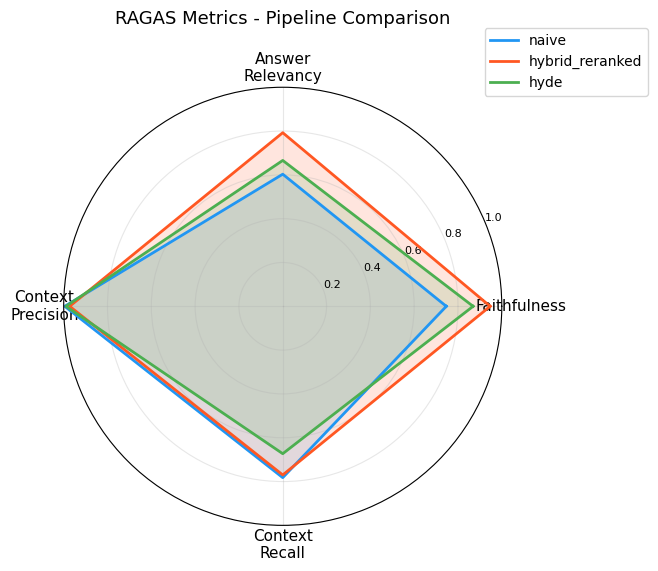

Radar chart saved.


In [16]:
# Radar chart - each config as a polygon across 4 metrics
categories = ["Faithfulness", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]
metric_keys = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close polygon

colors = ["#2196F3", "#FF5722", "#4CAF50"]
config_names = list(eval_results.keys())

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, config_name in enumerate(config_names):
    scores = eval_results[config_name]["scores"]
    values = [scores.get(k, 0) for k in metric_keys]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, color=colors[i], label=config_name)
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax.set_title("RAGAS Metrics - Pipeline Comparison", size=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ragas_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Radar chart saved.")

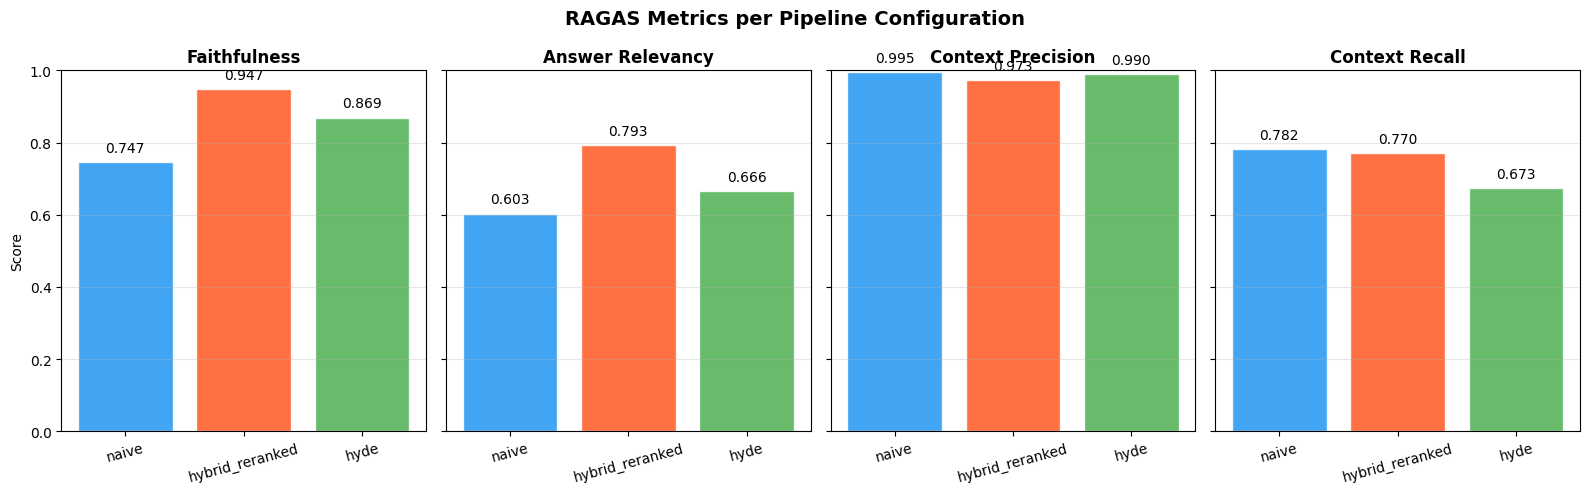

Bar chart saved.


In [17]:
# Bar chart - side-by-side per metric
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
metric_labels = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]

for ax, metric_key, metric_label in zip(axes, metric_keys, metric_labels):
    vals = [eval_results[c]["scores"].get(metric_key, 0) for c in config_names]
    bars = ax.bar(config_names, vals, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(metric_label, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10,
        )

fig.suptitle("RAGAS Metrics per Pipeline Configuration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ragas_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bar chart saved.")

In [22]:
# Per-category breakdown for each config
print("Per-category average scores:\n")

for config_name, res in eval_results.items():
    df = res["df"].copy()
    # Attach category from eval_questions
    cat_map = {q["question"]: q["category"] for q in eval_questions}
    df["category"] = df["user_input"].map(cat_map)

    cat_df = df.groupby("category")[metric_keys].mean().round(4)
    print(f"Config: {config_name}")
    print(cat_df.to_string())
    print()

Per-category average scores:

Config: naive
               faithfulness  answer_relevancy  context_precision  context_recall
category                                                                        
conceptual           0.6833            0.4587             1.0000          0.8889
error_related        0.6667            0.6485             0.9833          1.0000
how_to               0.9167            0.6655             1.0000          0.6286
technical            0.6667            0.6397             1.0000          0.6111

Config: hybrid_reranked
               faithfulness  answer_relevancy  context_precision  context_recall
category                                                                        
conceptual           0.9167            0.7838                1.0          1.0000
error_related        1.0000            0.8100                0.9          0.8056
how_to               1.0000            0.9417                1.0          0.5714
technical            0.8889            0

## 8. Save Results

In [23]:
output = {
    "experiment": "phase9_ragas_evaluation",
    "embed_model": EMBED_MODEL,
    "llm_model": LLM_MODEL,
    "n_questions": len(eval_questions),
    "results": [
        {
            "config": config_name,
            "scores": res["scores"],
            "avg_score": sum(res["scores"].values()) / len(res["scores"]),
            "avg_latency_ms": sum(s.latency_ms for s in res["samples"]) / len(res["samples"]),
            "eval_elapsed_s": res["elapsed_s"],
        }
        for config_name, res in eval_results.items()
    ],
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Results saved -> {RESULTS_PATH}")

Results saved -> D:\Astyan\rag-exploration\results\ragas_evaluation.json


## 9. Cleanup

In [24]:
# Delete evaluation collection to free disk space
import chromadb

client = chromadb.PersistentClient(path=str(PERSIST_DIR))
existing_collections = [c.name for c in client.list_collections()]

if COLLECTION_NAME in existing_collections:
    client.delete_collection(COLLECTION_NAME)
    print(f"Deleted collection '{COLLECTION_NAME}'")
else:
    print(f"Collection '{COLLECTION_NAME}' not found (already deleted?)")

print("Cleanup complete.")

Deleted collection 'ragas_eval_mxbai'
Cleanup complete.


## 10. Conclusion

### RAGAS Evaluation Results

| Config | Faithfulness | Answer Relevancy | Context Precision | Context Recall | Avg | Latency (ms) |
|--------|-------------|-----------------|-------------------|----------------|-----|-------------|
| naive | 0.7467 | 0.6031 | 0.9955 | 0.7821 | 0.7818 | 2995 |
| **hybrid_reranked** | **0.9470** | **0.7925** | 0.9727 | 0.7699 | **0.8705** | 4047 |
| hyde | 0.8690 | 0.6659 | 0.9898 | 0.6729 | 0.7994 | 8037 |

### Key Findings

**hybrid_reranked is the best pipeline** with the highest average score (0.87) at only +35% latency over naive. Cross-encoder reranking improves both faithfulness (+0.20 vs naive) and answer relevancy (+0.19 vs naive) by pushing the most relevant chunks to the top of the context.

**Context Precision is saturated** across all configs (~0.97-0.99). The vector store already returns relevant documents regardless of retrieval strategy. This metric does not differentiate pipelines on this corpus.

**HyDE is the worst trade-off**: 2.7x slower than naive (8s vs 3s) with the lowest context recall (0.67). The hypothetical document generated by Mistral 7B sometimes drifts from the original question, causing retrieval of off-topic chunks.

### Per-category insights

- **conceptual**: hybrid_reranked dominates (faithfulness 0.92, recall 1.0). Naive struggles (faithfulness 0.68).
- **error_related**: hybrid_reranked scores perfect faithfulness (1.0) and best relevancy (0.81).
- **how_to**: hybrid_reranked again best (faithfulness 1.0, relevancy 0.94), but context recall drops to 0.57 across all configs - how-to questions need broader context coverage.
- **technical**: HyDE surprisingly leads on relevancy (0.87) for technical questions, but hybrid_reranked is more balanced overall.

### Limitations

- **Small sample**: 12 questions (3 per category). Trends are clear but exact numbers have high variance.
- **Weak judge**: Mistral 7B struggles with RAGAS's internal JSON format, producing NaN values on some samples. A stronger judge model would give cleaner scores.
- **Circular evaluation**: Mistral 7B generates the answers AND judges them (except for context_recall which uses manual ground truths). This inflates faithfulness and relevancy scores for all configs.

### Recommendation for Phase 10

Use **hybrid_reranked** (BM25 + dense ensemble, cross-encoder reranking) as the default pipeline configuration. It delivers the best end-to-end quality with acceptable latency overhead.